[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/Practica_guiada3_OSMnx.ipynb)

# Práctica guiada 3 — El callejero como red, con OSMnx

En las prácticas anteriores construimos grafos a mano: definimos los nodos, los
conectamos, les pusimos atributos. Eso funciona para una red de nueve
estaciones, pero no para una ciudad.

[OSMnx](https://osmnx.readthedocs.io/) resuelve ese problema: descarga datos de
[OpenStreetMap](https://www.openstreetmap.org) y los devuelve como un grafo de
NetworkX, ya listo para analizar. Las **intersecciones son los nodos** y las
**calles son los ejes**.

Vamos a recorrer cuatro cosas:

1. Descargar geometrías (edificios, usos de suelo, límites).
2. Construir una red de calles — hay cinco formas de hacerlo.
3. Describirla: simplificación, atributos, métricas.
4. Rutear sobre ella.

El territorio de trabajo es **José León Suárez** (Partido de General San
Martín), y en particular los barrios **Villa Hidalgo** y **La Cárcova**.

## Setup

> **Nota sobre versiones.** Este notebook usa OSMnx **2.x**. Si venís de
> material escrito para 1.x, cinco cosas cambiaron: `ox.config()` se reemplaza
> por `ox.settings`, `graph_from_bbox` ahora recibe **una tupla**
> `(oeste, sur, este, norte)` en vez de cuatro argumentos en el orden
> `(norte, sur, este, oeste)`, `ox.project_gdf()` se reemplaza por
> `.to_crs(gdf.estimate_utm_crs())`, `.unary_union` por `.union_all()`, y casi
> todos los parámetros pasaron a ser *keyword-only*.

In [1]:
%pip install -q osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.3 MB/s eta 0:00:00


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd

# use_cache evita volver a pegarle a la API de OSM con la misma consulta:
# la primera corrida tarda, las siguientes son instantáneas.
ox.settings.use_cache = True
ox.settings.log_file = True

print(f"OSMnx {ox.__version__}")

OSMnx 2.1.1


In [3]:
from google.colab import drive

drive.mount("/drive/")

DATA_DIR = "/drive/MyDrive/transport-networks-lab/Data"

Mounted at /drive/


In [4]:
# Constantes que se usan a lo largo de todo el notebook
LOCALIDAD = "José León Suárez, Partido de General San Martín, Buenos Aires, Argentina"

# Centroide de Villa Hidalgo (lat, lon) — punto de referencia para las descargas
REFERENCIA = (-34.50944, -58.58610)

# Bounding box que cubre Villa Hidalgo y La Cárcova.
# OSMnx 2.x lo espera como (oeste, sur, este, norte).
BBOX = (-58.589830, -34.533818, -58.566442, -34.506274)

## Sección 1. Descargar geometrías

Antes de las calles, veamos que OSMnx puede traer **cualquier** entidad de OSM
con el módulo `features`: edificios, escuelas, paradas de colectivo, usos de
suelo.

Las consultas se arman con un diccionario de [tags de OSM](https://wiki.openstreetmap.org/wiki/Map_features).
La clave es el tag; el valor puede ser `True` (todo lo que tenga ese tag), un
string (una subcategoría) o una lista de strings.

Cada familia `features_from_*` se diferencia en **cómo se delimita el área**,
igual que los constructores de grafos que veremos después. Acá usamos
`features_from_bbox` con el bounding box que definimos arriba.

> **Por qué el bbox y no el nombre del lugar.** `features_from_place` primero
> geocodifica el nombre contra Nominatim y necesita que devuelva un **polígono**.
> Muchos lugares —José León Suárez entre ellos— resuelven a un *punto*, y la
> consulta falla con `TypeError: Nominatim did not geocode query ... to a
> geometry of type (Multi)Polygon`. El bbox no depende del geocodificador, así
> que es reproducible y no se rompe si mañana cambia el dato en OSM. La
> Sección 1.1 muestra cómo averiguar de antemano qué lugares sí tienen polígono.

In [5]:
edificios = ox.features_from_bbox(bbox=BBOX, tags={"building": True})
print(f"{len(edificios)} edificios descargados")

usos_suelo = ox.features_from_bbox(bbox=BBOX, tags={"landuse": ["residential", "landfill"]})
print(f"{len(usos_suelo)} polígonos de uso de suelo")
print(f"   usos presentes: {sorted(usos_suelo.landuse.dropna().unique())}")

INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Resolved 'overpass-api.de' to '162.55.144.139'
INFO:OSMnx:Pausing 0 second(s) before making HTTP POST request to 'overpass-api.de'
INFO:OSMnx:Post https://overpass-api.de/api/interpreter?data=%5Bout%3Ajson%5D%5Btimeout%3A180%5D%3B%28%28node%5B%27building%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%28way%5B%27building%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%28relation%5B%27building%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%29%3Bout%3B with

161 edificios descargados


INFO:OSMnx:Pausing 0 second(s) before making HTTP POST request to 'overpass-api.de'
INFO:OSMnx:Post https://overpass-api.de/api/interpreter?data=%5Bout%3Ajson%5D%5Btimeout%3A180%5D%3B%28%28node%5B%27landuse%27%3D%27residential%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%28way%5B%27landuse%27%3D%27residential%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%28relation%5B%27landuse%27%3D%27residential%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%28node%5B%27landuse%27%3D%27landfill%27%5D%28poly%3A%27-34.533818+-58.589830+-34.533818+-58.566442+-34.506274+-58.566442+-34.506274+-58.589830+-34.533818+-58.589830%27%29%3B%28._%3B%3E%3B%29%3B%29%3B%2

23 polígonos de uso de suelo
   usos presentes: ['residential']


/tmp/ipykernel_5155/3911609922.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")


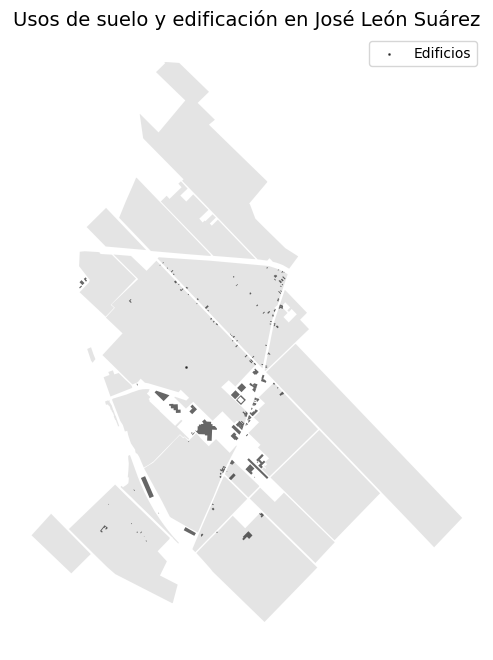

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# Cada capa puede venir vacía según lo que haya cargado en OSM,
# así que sólo ploteamos las que tienen algo.
capas = [
    (usos_suelo[usos_suelo.landuse == "residential"], "Residencial", "lightgrey"),
    (usos_suelo[usos_suelo.landuse == "landfill"], "Basural", "saddlebrown"),
    (edificios, "Edificios", "black"),
]
for capa, etiqueta, color in capas:
    if not capa.empty:
        capa.plot(ax=ax, color=color, markersize=1, alpha=0.6, label=etiqueta)

ax.set_axis_off()
ax.legend(loc="upper right")
ax.set_title("Usos de suelo y edificación en José León Suárez", fontsize=14)
plt.show()

La proximidad entre el basural y el tejido residencial es visible de entrada.
Es el tipo de pregunta que este dataset permite empezar a formular.

### 1.1. ¿Qué lugares tienen polígono en OSM?

OSM es colaborativo y la cobertura es despareja: algunos lugares tienen su
límite administrativo cargado y otros sólo existen como un punto. Antes de usar
cualquier método `*_from_place`, conviene chequearlo.

In [7]:
from osmnx._errors import InsufficientResponseError

CONSULTAS = [
    "José León Suárez, Partido de General San Martín, Buenos Aires, Argentina",
    "Villa Ballester, Buenos Aires, Argentina",
    "Loma Hermosa, Buenos Aires, Argentina",
    "Partido de General San Martín, Buenos Aires, Argentina",
]


def geocodificar(consultas):
    """Geocodifica cada consulta y reporta cuáles devolvieron un polígono.

    Returns:
        (DataFrame con el diagnóstico, GeoDataFrame con las que funcionaron)
    """
    filas, geoms = [], []
    for q in consultas:
        try:
            gdf = ox.geocode_to_gdf(q)
            filas.append({"consulta": q, "geometría": gdf.geometry.iloc[0].geom_type})
            geoms.append(gdf)
        except (TypeError, InsufficientResponseError):
            filas.append({"consulta": q, "geometría": "sin polígono"})

    resultados = gpd.GeoDataFrame(pd.concat(geoms, ignore_index=True)) if geoms else gpd.GeoDataFrame()
    return pd.DataFrame(filas), resultados


diagnostico, limites = geocodificar(CONSULTAS)
diagnostico

INFO:OSMnx:Pausing 1 second(s) before making HTTP GET request to 'nominatim.openstreetmap.org'
INFO:OSMnx:Get https://nominatim.openstreetmap.org/search?format=json&polygon_geojson=1&dedupe=0&limit=50&q=Jos%C3%A9+Le%C3%B3n+Su%C3%A1rez%2C+Partido+de+General+San+Mart%C3%ADn%2C+Buenos+Aires%2C+Argentina with timeout=180
INFO:OSMnx:Downloaded 1.8kB from 'nominatim.openstreetmap.org' with status 200
INFO:OSMnx:Saved response to cache file 'cache/5b32fae13fa4d6fe29e745a7452752ab1cd21c3b.json'
INFO:OSMnx:Pausing 1 second(s) before making HTTP GET request to 'nominatim.openstreetmap.org'
INFO:OSMnx:Get https://nominatim.openstreetmap.org/search?format=json&polygon_geojson=1&dedupe=0&limit=50&q=Villa+Ballester%2C+Buenos+Aires%2C+Argentina with timeout=180
INFO:OSMnx:Downloaded 2.4kB from 'nominatim.openstreetmap.org' with status 200
INFO:OSMnx:Saved response to cache file 'cache/960f6ae4a321f766a042bc1fa959bb1e16deb8f5.json'
INFO:OSMnx:Pausing 1 second(s) before making HTTP GET request to 'nomi

,consulta,geometría
0,"José León Suárez, Partido de General San Martí...",sin polígono
1,"Villa Ballester, Buenos Aires, Argentina",sin polígono
2,"Loma Hermosa, Buenos Aires, Argentina",Polygon
3,"Partido de General San Martín, Buenos Aires, A...",Polygon


La tabla explica el error del principio: la consulta de José León Suárez no
devuelve un polígono, y por eso `features_from_place` fallaba. **No es un bug
del código, es un dato que falta en OSM.**

De acá salen dos reglas prácticas:

- Si necesitás reproducibilidad, delimitá con un **bbox o un polígono propio**.
  No dependen del geocodificador.
- Si usás `*_from_place`, chequeá primero que la consulta resuelva a polígono.
  Cuanto más específica es la consulta, más probable es que falle.

## Sección 2. Construir la red de calles

Acá está el corazón de OSMnx. Hay **cinco formas** de pedir una red, y se
diferencian sólo en cómo se define el área:

| Método | Se define con | Cuándo conviene |
|---|---|---|
| `graph_from_bbox` | 4 coordenadas | Recorte arbitrario y reproducible |
| `graph_from_point` | 1 punto + distancia | Área alrededor de un lugar |
| `graph_from_address` | 1 dirección + distancia | Igual, pero geocodificando |
| `graph_from_place` | Nombre de un lugar | Usar el límite oficial de OSM |
| `graph_from_polygon` | Un polígono propio | Cuando ya tenés la geometría |

Todos devuelven lo mismo: un `MultiDiGraph`. Construyámoslos juntos y
comparemos. `graph_from_place` tiene la misma dependencia del geocodificador
que vimos recién, así que lo envolvemos para que un fallo no corte la celda.

In [8]:
def construir(nombre, fn, **kwargs):
    """Construye un grafo y avisa si la consulta falla, sin cortar la celda."""
    try:
        return fn(**kwargs)
    except Exception as e:
        print(f"{nombre} falló: {type(e).__name__} — {e}")
        return None


candidatos = {
    "from_bbox": (ox.graph_from_bbox,
                  dict(bbox=BBOX, network_type="drive_service")),
    "from_point": (ox.graph_from_point,
                   dict(center_point=REFERENCIA, dist=500, network_type="drive")),
    "from_address": (ox.graph_from_address,
                     dict(address="Doctor Ricardo Balbin, Partido de General San Martín, "
                                  "Buenos Aires, Argentina",
                          dist=1000, dist_type="network", network_type="drive")),
    "from_place": (ox.graph_from_place,
                   dict(query="Villa Ballester, Buenos Aires, Argentina",
                        network_type="drive")),
}

grafos = {n: G for n, (fn, kw) in candidatos.items()
          if (G := construir(n, fn, **kw)) is not None}

comparacion = pd.DataFrame(
    {"tipo": type(G).__name__, "nodos": G.number_of_nodes(), "ejes": G.number_of_edges()}
    for G in grafos.values()
).set_index(pd.Index(grafos.keys(), name="método"))

comparacion

INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Resolved 'overpass-api.de' to '162.55.144.139'
INFO:OSMnx:Pausing 29 second(s) before making HTTP POST request to 'overpass-api.de'
INFO:OSMnx:Post https://overpass-api.de/api/interpreter?data=%5Bout%3Ajson%5D%5Btimeout%3A180%5D%3B%28way%5B%22highway%22%5D%5B%22area%22%21~%22yes%22%5D%5B%22access%22%21~%22private%22%5D%5B%22highway%22%21~%22abandoned%7Cbridleway%7Cbus_guideway%7Cconstruction%7Ccorridor%7Ccycleway%7Celevator%7Cescalator%7Cfootway%7Cno%7Cpath%7Cpedestrian%7Cplanned%7Cplatform%7Cproposed%7Craceway%7Crazed%7Crest_area%7Cservices%7Csteps%7Ctrack%22%5D%5B%22motor_vehicle%22%21~%22no%22%5D%5B%22motorcar%22%21~%22no%22%5D%5B%22service%22%21~%22emergency_ac

from_place falló: TypeError — Nominatim did not geocode query 'Villa Ballester, Buenos Aires, Argentina' to a geometry of type (Multi)Polygon.


,tipo,nodos,ejes
método,,,
from_bbox,MultiDiGraph,698,1800
from_point,MultiDiGraph,66,194
from_address,MultiDiGraph,155,292


INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph
INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph
INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph


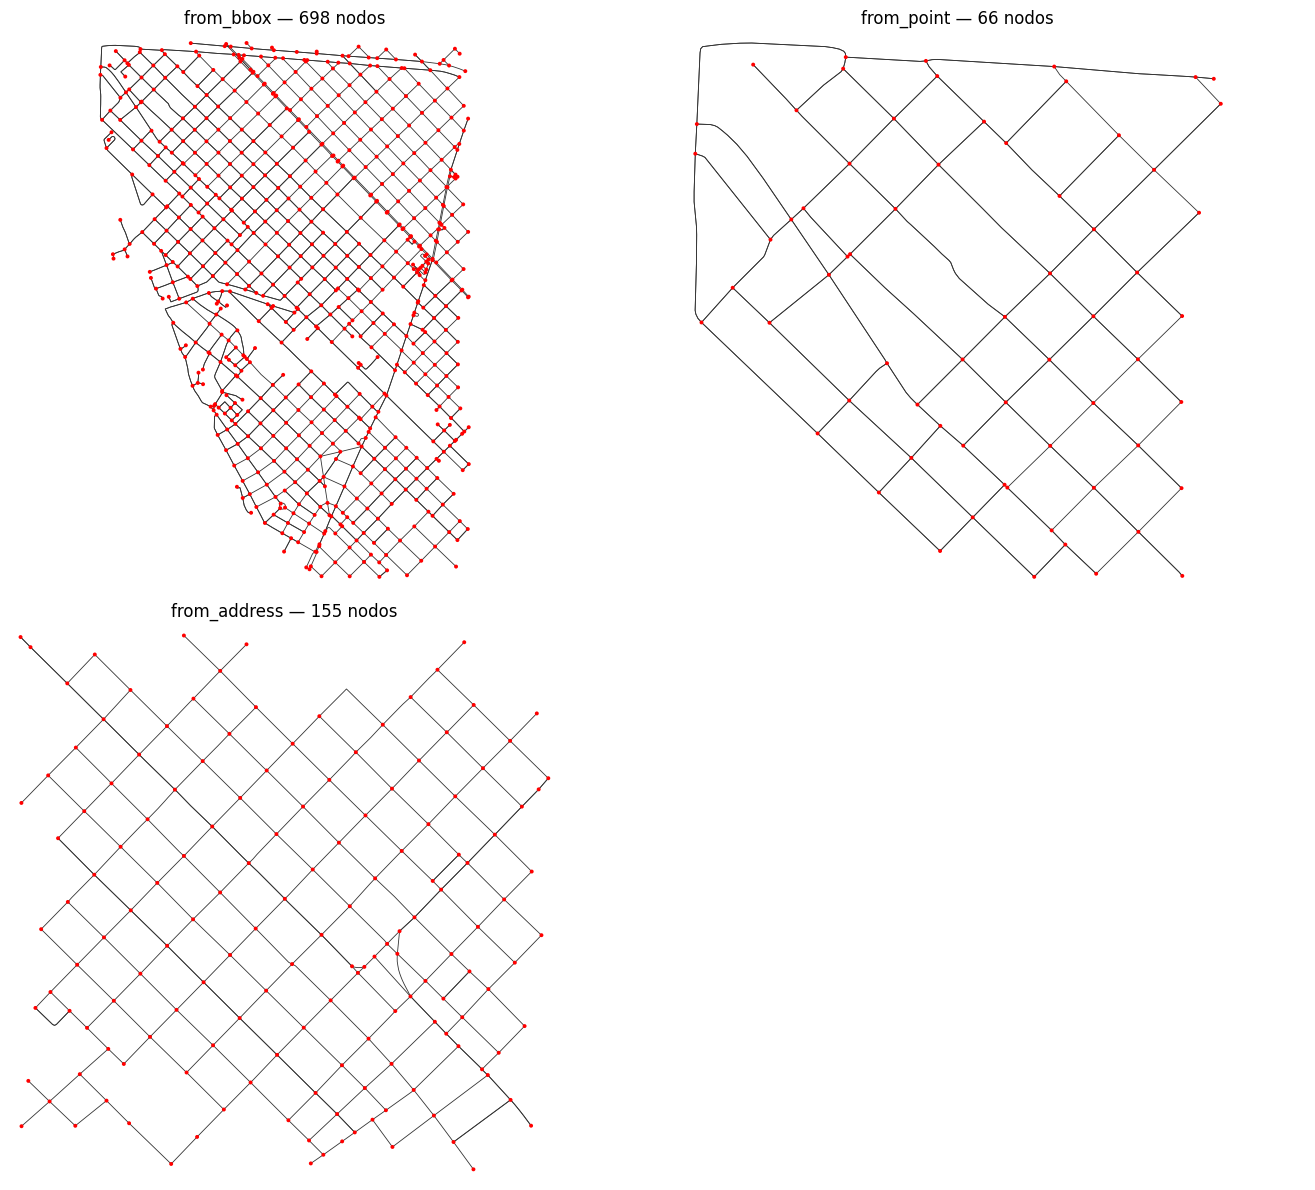

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (nombre, G) in zip(axes.flat, grafos.items()):
    ox.plot_graph(G, ax=ax, show=False, close=False,
                  bgcolor="white", node_color="red", node_size=8,
                  edge_color="#333333", edge_linewidth=0.6)
    ax.set_title(f"{nombre} — {G.number_of_nodes()} nodos")

# Apagamos los ejes que sobren si alguna consulta falló
for ax in axes.flat[len(grafos):]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

Todos devuelven un `MultiDiGraph`: **dirigido** (las calles tienen sentido) y
**multi** (puede haber más de una calle entre dos esquinas). Es exactamente la
clase que en la práctica 2 elegimos para los viajes de EcoBici, y por los
mismos motivos.

### 2.1. El quinto método: desde un polígono propio

Los cuatro anteriores dejan que OSM defina el área. `graph_from_polygon`
invierte eso: le pasamos nuestra propia geometría. Lo usamos con el
[RENABAP](https://www.argentina.gob.ar/desarrollosocial/renabap), el registro
nacional de barrios populares.

   nombre_bar    provincia         departamen
Villa Hidalgo Buenos Aires General San Martín
   La Carcova Buenos Aires General San Martín


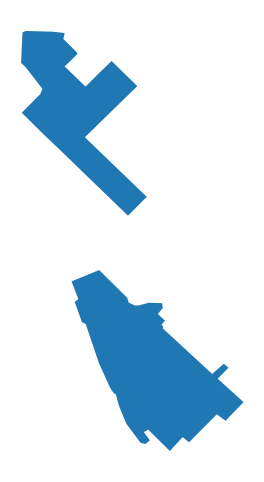

In [10]:
barrios = gpd.read_file(f"{DATA_DIR}/renabap.geojson")

barrios_ls = barrios[
    (barrios.provincia == "Buenos Aires")
    & (barrios.departamen == "General San Martín")
    & (barrios.nombre_bar.isin(["Villa Hidalgo", "La Carcova"]))
].copy()

print(barrios_ls[["nombre_bar", "provincia", "departamen"]].to_string(index=False))
barrios_ls.plot(figsize=(6, 6)).set_axis_off()

INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Resolved 'overpass-api.de' to '162.55.144.139'
INFO:OSMnx:Pausing 8 second(s) before making HTTP POST request to 'overpass-api.de'
INFO:OSMnx:Post https://overpass-api.de/api/interpreter?data=%5Bout%3Ajson%5D%5Btimeout%3A180%5D%3B%28way%5B%22highway%22%5D%5B%22area%22%21~%22yes%22%5D%5B%22access%22%21~%22private%22%5D%5B%22highway%22%21~%22abandoned%7Cbus_guideway%7Cconstruction%7Ccycleway%7Cmotor%7Cno%7Cplanned%7Cplatform%7Cproposed%7Craceway%7Crazed%7Crest_area%7Cservices%22%5D%5B%22foot%22%21~%22no%22%5D%5B%22service%22%21~%22private%22%5D%5B%22sidewalk%22%21~%22separate%22%5D%5B%22sidewalk%3Aboth%22%21~%22separate%22%5D%5B%22sidewalk%3Aleft%22%21~%22separate%22

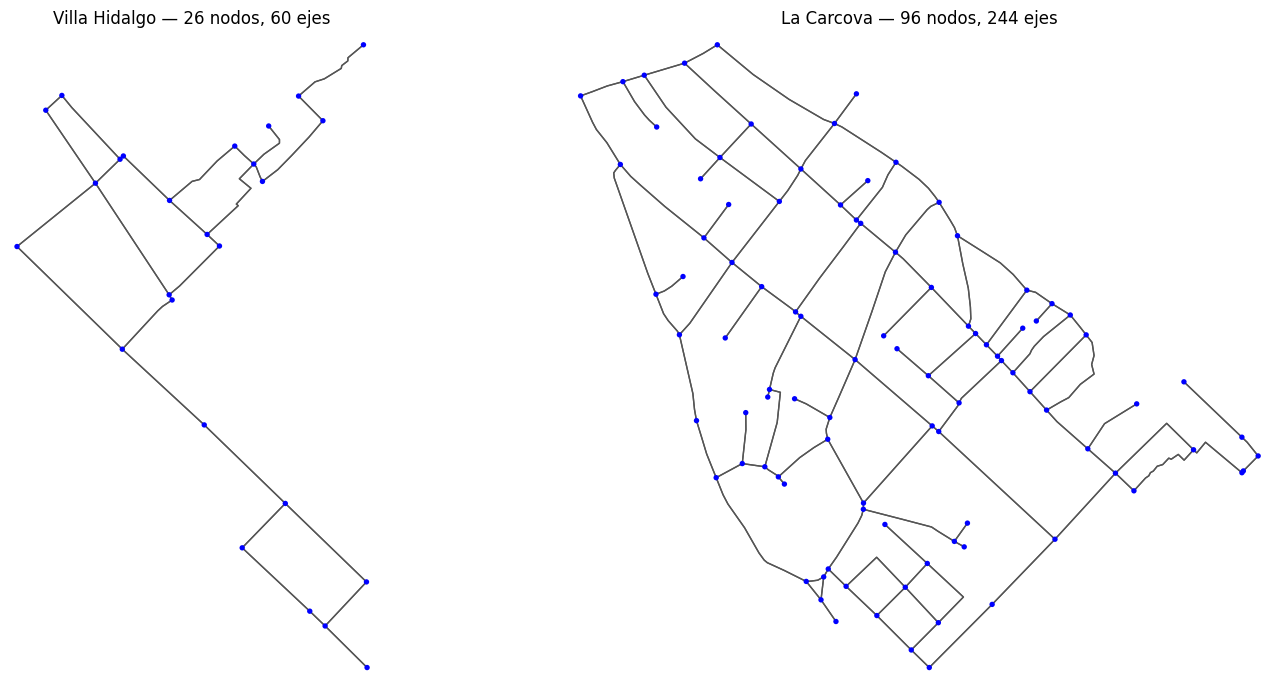

In [11]:
redes_barrios = {
    r.nombre_bar: ox.graph_from_polygon(r.geometry, network_type="walk")
    for r in barrios_ls.itertuples()
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (nombre, G) in zip(axes, redes_barrios.items()):
    ox.plot_graph(G, ax=ax, show=False, close=False,
                  bgcolor="white", node_color="blue", node_size=15,
                  edge_color="#555555", edge_linewidth=1)
    ax.set_title(f"{nombre} — {G.number_of_nodes()} nodos, {G.number_of_edges()} ejes")
plt.tight_layout()
plt.show()

### 2.2. `network_type`: qué se considera una calle

El parámetro `network_type` filtra qué vías entran en la red:

- `drive` — vías de tránsito vehicular
- `drive_service` — idem, más colectoras y calles de servicio
- `walk` — todo lo transitable a pie (**ignora el sentido único**)
- `bike` — vías habilitadas para bicicletas
- `all` / `all_private` — cualquier vía, con o sin acceso privado

No es un detalle cosmético: cambia la red que se analiza.

INFO:OSMnx:Created bbox 500 meters from (-34.50944, -58.5861): (np.float64(-58.591556823280776), np.float64(-34.513936601677464), np.float64(-58.58064317671923), np.float64(-34.50494339832253))
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Retrieved response from cache file 'cache/309e722814a06f9e5a4bd417a03db15e1e9b5735.json'
INFO:OSMnx:Retrieved all data from API in 1 request(s)
INFO:OSMnx:Creating graph from 884 OSM nodes and 269 OSM ways...
INFO:OSMnx:Created graph with 884 nodes and 1,761 edges
INFO:OSMnx:Added length attributes to graph edges
INFO:OSMnx:Identifying all nodes that lie outside the polygon...
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Built r-tree spatial index for 884 geom

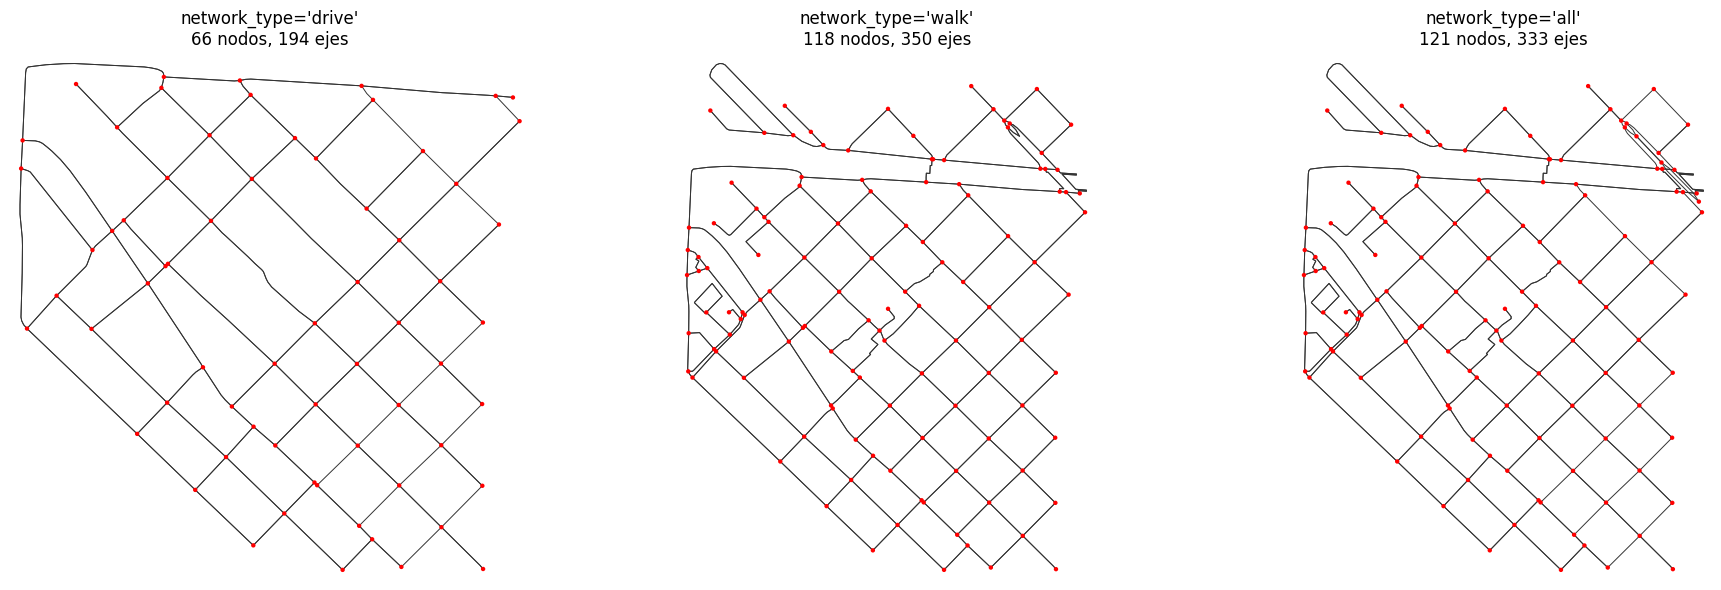

In [12]:
tipos = ["drive", "walk", "all"]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, t in zip(axes, tipos):
    G = ox.graph_from_point(REFERENCIA, dist=500, network_type=t)
    ox.plot_graph(G, ax=ax, show=False, close=False,
                  bgcolor="white", node_color="red", node_size=10,
                  edge_color="#333333", edge_linewidth=0.7)
    ax.set_title(f"network_type='{t}'\n{G.number_of_nodes()} nodos, {G.number_of_edges()} ejes")
plt.tight_layout()
plt.show()

`walk` produce muchos más ejes que `drive`, y no porque haya más calles: al
ignorar el sentido único, cada calle se vuelve bidireccional. En un asentamiento
informal la diferencia es aún mayor, porque los pasillos peatonales no están
mapeados como vías vehiculares.

### 2.3. `dist_type`: distancia en línea recta o sobre la red

INFO:OSMnx:Created bbox 500 meters from (-34.50944, -58.5861): (np.float64(-58.591556823280776), np.float64(-34.513936601677464), np.float64(-58.58064317671923), np.float64(-34.50494339832253))
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Retrieved response from cache file 'cache/309e722814a06f9e5a4bd417a03db15e1e9b5735.json'
INFO:OSMnx:Retrieved all data from API in 1 request(s)
INFO:OSMnx:Creating graph from 884 OSM nodes and 269 OSM ways...
INFO:OSMnx:Created graph with 884 nodes and 1,761 edges
INFO:OSMnx:Added length attributes to graph edges
INFO:OSMnx:Identifying all nodes that lie outside the polygon...
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Built r-tree spatial index for 884 geom

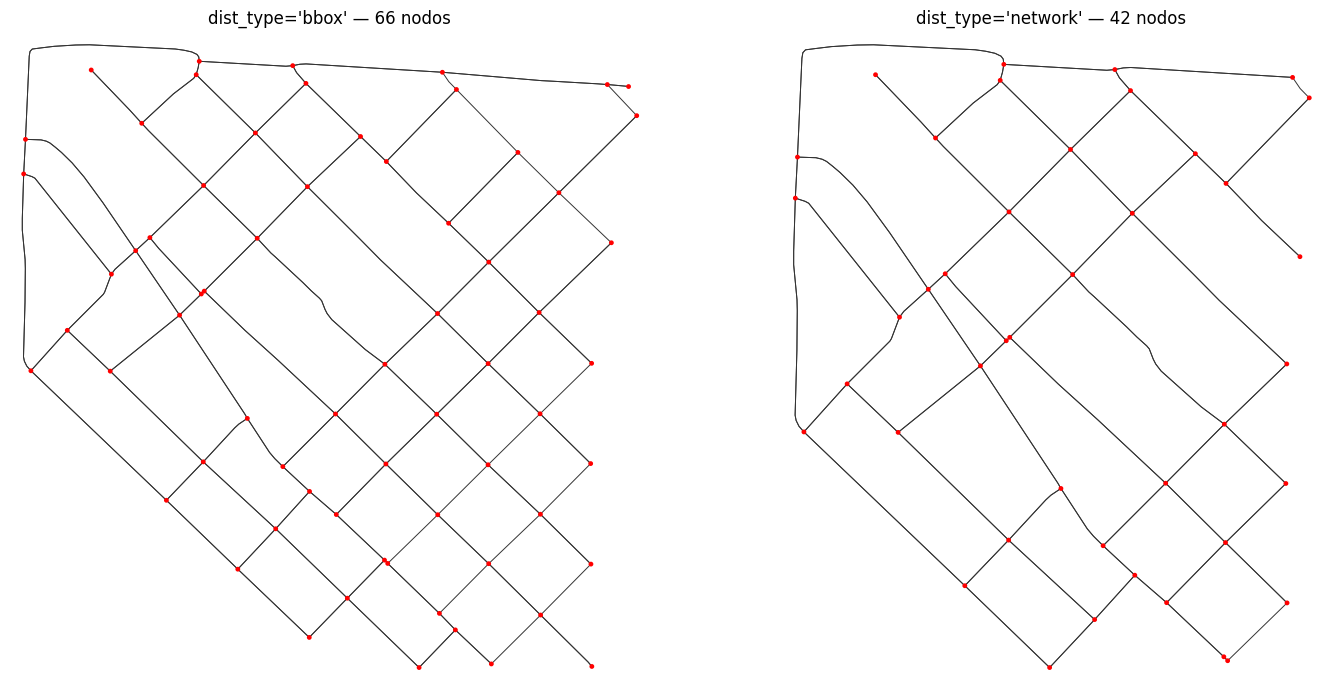

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, dt in zip(axes, ["bbox", "network"]):
    G = ox.graph_from_point(REFERENCIA, dist=500, dist_type=dt, network_type="drive")
    ox.plot_graph(G, ax=ax, show=False, close=False,
                  bgcolor="white", node_color="red", node_size=12,
                  edge_color="#333333", edge_linewidth=0.7)
    ax.set_title(f"dist_type='{dt}' — {G.number_of_nodes()} nodos")

plt.tight_layout()
plt.show()

Con `bbox` el recorte es un cuadrado de 500 m de lado. Con `network` se
eliminan los nodos que están a más de 500 m **recorriendo la red**, lo que da
una forma irregular: es la diferencia entre "cerca en el mapa" y "cerca para
quien camina". La segunda es casi siempre la pregunta relevante en transporte.

## Sección 3. Simplificar la topología

Los nodos de OSM no son todos intersecciones. Muchos son sólo vértices que
describen la **curvatura** de una calle. Para la geometría son necesarios; para
el grafo son ruido: no representan una decisión de a dónde ir.

In [14]:
G_crudo = ox.graph_from_point(REFERENCIA, dist=500, network_type="walk", simplify=False)
G_simple = ox.simplify_graph(G_crudo)

print(f"Sin simplificar: {G_crudo.number_of_nodes():>5} nodos, {G_crudo.number_of_edges():>5} ejes")
print(f"Simplificado:    {G_simple.number_of_nodes():>5} nodos, {G_simple.number_of_edges():>5} ejes")
print(f"\nSe eliminó el {1 - G_simple.number_of_nodes() / G_crudo.number_of_nodes():.0%} de los nodos")

INFO:OSMnx:Created bbox 500 meters from (-34.50944, -58.5861): (np.float64(-58.591556823280776), np.float64(-34.513936601677464), np.float64(-58.58064317671923), np.float64(-34.50494339832253))
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Retrieved response from cache file 'cache/f2a8611024014e65cba946a2a402c6a8674f8f24.json'
INFO:OSMnx:Retrieved all data from API in 1 request(s)
INFO:OSMnx:Creating graph from 1,056 OSM nodes and 310 OSM ways...
INFO:OSMnx:Created graph with 1,056 nodes and 2,590 edges
INFO:OSMnx:Added length attributes to graph edges
INFO:OSMnx:Identifying all nodes that lie outside the polygon...
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Built r-tree spatial index for 1,05

Sin simplificar:   263 nodos,   638 ejes
Simplificado:      102 nodos,   316 ejes

Se eliminó el 61% de los nodos


INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph
INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph


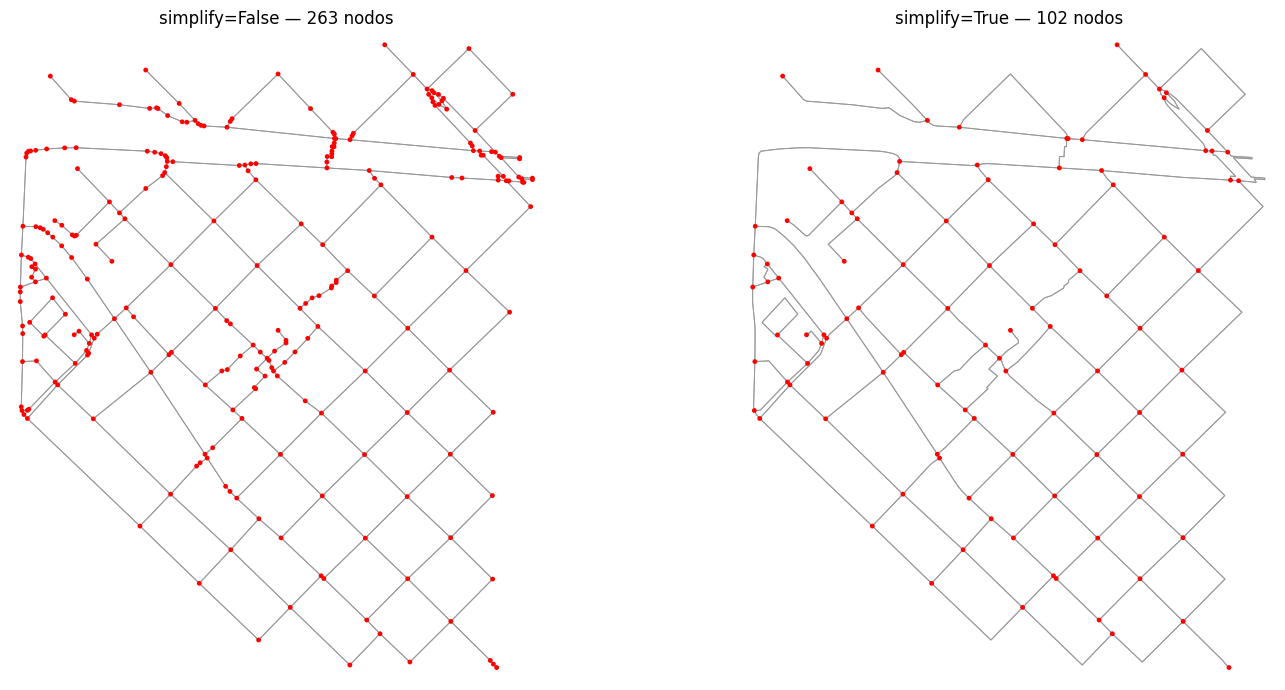

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (G, t) in zip(axes, [(G_crudo, "simplify=False"), (G_simple, "simplify=True")]):
    ox.plot_graph(G, ax=ax, show=False, close=False,
                  bgcolor="black", node_color="red", node_size=12, edge_linewidth=0.7)
    ax.set_title(f"{t} — {G.number_of_nodes()} nodos", color="black")
plt.tight_layout()
plt.show()

La forma de las calles es idéntica: la geometría se conserva como atributo de
cada eje. Lo que desaparece son los nodos intermedios. Un eje simplificado
guarda el trazado completo, pero topológicamente conecta dos intersecciones y
nada más.

`graph_from_*` simplifica por defecto (`simplify=True`), así que en general esto
ya viene resuelto. Verlo explícitamente aclara **por qué** el conteo de nodos de
OSMnx no coincide con el de OSM.

## Sección 4. La red como tabla

Un grafo de OSMnx se convierte en dos GeoDataFrames con `graph_to_gdfs`: uno de
nodos y otro de ejes. Es la forma más cómoda de mirar los atributos.

In [16]:
G = ox.graph_from_polygon(
    barrios_ls[barrios_ls.nombre_bar == "La Carcova"].geometry.iloc[0],
    network_type="drive_service",
)

nodos, ejes = ox.graph_to_gdfs(G)
print(f"nodos: {nodos.shape}   ejes: {ejes.shape}")
ejes[["name", "highway", "oneway", "length", "geometry"]].head()

INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:4326 / WGS 84'
INFO:OSMnx:Requesting data from API in 1 request(s)
INFO:OSMnx:Resolved 'overpass-api.de' to '162.55.144.139'
INFO:OSMnx:Pausing 21 second(s) before making HTTP POST request to 'overpass-api.de'
INFO:OSMnx:Post https://overpass-api.de/api/interpreter?data=%5Bout%3Ajson%5D%5Btimeout%3A180%5D%3B%28way%5B%22highway%22%5D%5B%22area%22%21~%22yes%22%5D%5B%22access%22%21~%22private%22%5D%5B%22highway%22%21~%22abandoned%7Cbridleway%7Cbus_guideway%7Cconstruction%7Ccorridor%7Ccycleway%7Celevator%7Cescalator%7Cfootway%7Cno%7Cpath%7Cpedestrian%7Cplanned%7Cplatform%7Cproposed%7Craceway%7Crazed%7Crest_area%7Cservices%7Csteps%7Ctrack%22%5D%5B%22motor_vehicle%22%21~%22no%22%5D%5B%22motorcar%22%21~%22no%22%5D%5B%22service%22%21~%22emergency_ac

nodos: (53, 4)   ejes: (129, 9)


name  \
u         v          key                                                    
684364414 684398538  0                            Diagonal 41 - Costanera   
          684393374  0    [Diagonal 41 - Costanera, 55 - Avenida Central]   
684364421 684364414  0                                     51 - 1 de Mayo   
          684393409  0                                         2 De Abril   
          2506002705 0                                         2 De Abril   

                              highway  oneway      length  \
u         v          key                                    
684364414 684398538  0    residential   False   43.118816   
          684393374  0    residential   False  216.377311   
684364421 684364414  0    residential    True  180.358697   
          684393409  0    residential   False  133.420724   
          2506002705 0    residential   False   64.959496   

                                                                   geometry  
u         v          key                                                     
684364414 684398538  0    LINESTRING (-58.58406 -34.51958, -58.58383 -34...  
          684393374  0    LINESTRING (-58.58406 -34.51958, -58.58456 -34...  
684364421 684364414  0    LINESTRING (-58.5826 -34.52067, -58.58322 -34....  
          684393409  0    LINESTRING (-58.5826 -34.52067, -58.58264 -34....  
          2506002705 0    LINESTRING (-58.5826 -34.52067, -58.58255 -34....

In [17]:
# Estadística rápida de los atributos que más se usan
print(ejes.length.describe().round(1).to_string())
print(f"\nCalles de sentido único: {ejes.oneway.sum()} de {len(ejes)}")

/tmp/ipykernel_5155/2704061818.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(ejes.length.describe().round(1).to_string())


count    129.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0

Calles de sentido único: 9 de 129


### 4.1. Pintar la red por atributo

INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph
INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph


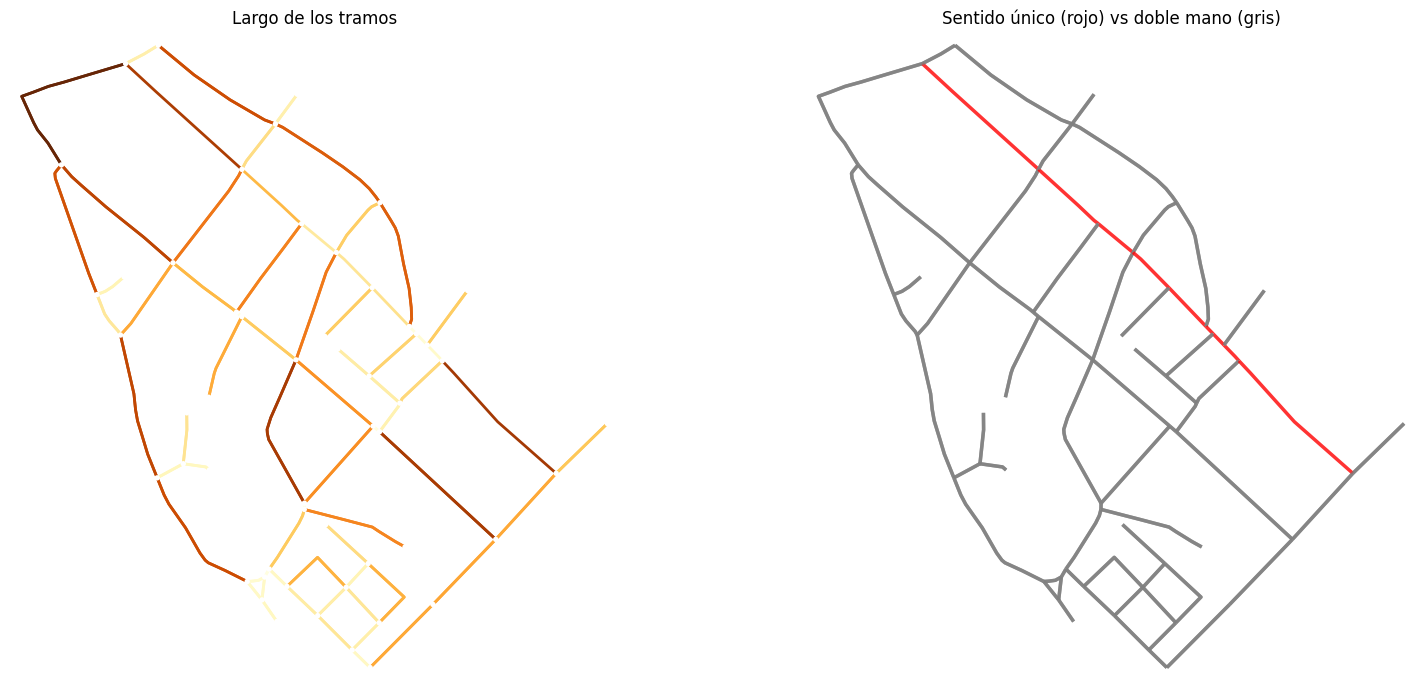

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Largo de cada tramo
colores_largo = ox.plot.get_edge_colors_by_attr(G, attr="length", cmap="YlOrBr")
ox.plot_graph(G, ax=axes[0], show=False, close=False,
              bgcolor="black", node_color="w", node_size=15,
              edge_color=colores_largo, edge_linewidth=2)
axes[0].set_title("Largo de los tramos")

# Sentido único vs doble mano
colores_sentido = ["red" if d["oneway"] else "grey"
                   for _, _, d in G.edges(data=True)]
ox.plot_graph(G, ax=axes[1], show=False, close=False,
              bgcolor="white", node_size=0,
              edge_color=colores_sentido, edge_linewidth=2.5, edge_alpha=0.8)
axes[1].set_title("Sentido único (rojo) vs doble mano (gris)")

plt.tight_layout()
plt.show()

## Sección 5. Métricas de la red

`basic_stats` resume la topología en un diccionario: cantidad de nodos y ejes,
largo total y promedio de las calles, circuidad, cantidad de intersecciones.

In [19]:
stats = ox.basic_stats(G)

pd.Series({k: v for k, v in stats.items() if isinstance(v, (int, float))}).round(2)

INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Converted MultiDiGraph to undirected MultiGraph


,0
n,53.00
m,129.00
k_avg,4.87
edge_length_total,10534.52
edge_length_avg,81.66
streets_per_node_avg,2.75
intersection_count,42.00
street_length_total,5608.71
street_segment_count,69.00
street_length_avg,81.29


Dos que vale la pena mirar:

- **`circuity_avg`** — cuánto más largo es el recorrido real que la línea recta.
  Un valor de 1,00 sería una grilla perfecta; cuanto más alto, más sinuosa la
  traza.
- **`streets_per_node_avg`** — cuántas calles nacen de cada intersección en
  promedio. Cerca de 4 indica damero; cerca de 3, calles sin salida y ramificaciones.

### 5.1. Densidad

Pasándole el `area` en m², `basic_stats` agrega métricas de densidad.

In [20]:
poligono = barrios_ls[barrios_ls.nombre_bar == "La Carcova"]

# En OSMnx 2.x se reemplaza ox.project_gdf() por estimate_utm_crs()
area_m2 = poligono.to_crs(poligono.estimate_utm_crs()).geometry.union_all().area
print(f"Área: {area_m2 / 1e6:.3f} km²\n")

stats = ox.basic_stats(G, area=area_m2)
for k, v in stats.items():
    if "density" in k:
        print(f"{k:28s} {v:,.1f}")

INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Converted MultiDiGraph to undirected MultiGraph


Área: 0.381 km²

node_density_km              139.0
intersection_density_km      110.2
edge_density_km              27,632.4
street_density_km            14,711.8


### 5.2. Betweenness centrality

En la práctica 1 vimos que la intermediación identifica los nodos por los que
pasan más caminos mínimos. Sobre un callejero real, esos nodos son las
**esquinas críticas**: si se cortan, la circulación se reorganiza o se
interrumpe.

Acá lo calculamos ponderando por `length`, así los caminos mínimos son en
metros y no en cantidad de tramos.

In [21]:
G_proj = ox.project_graph(G)

nodo_bc = nx.betweenness_centrality(G_proj, weight="length", normalized=True)

top = (
    pd.Series(nodo_bc, name="betweenness")
    .sort_values(ascending=False)
    .head(5)
    .round(3)
)
print("Nodos más críticos:")
print(top.to_string())

INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Validated that node/edge GeoDataFrames can be converted to a MultiDiGraph.
INFO:OSMnx:Created graph from node/edge GeoDataFrames
INFO:OSMnx:Projected graph with 53 nodes and 129 edges


Nodos más críticos:
684370366     0.391
3029782600    0.316
987449333     0.306
987449342     0.294
684370418     0.284


INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph


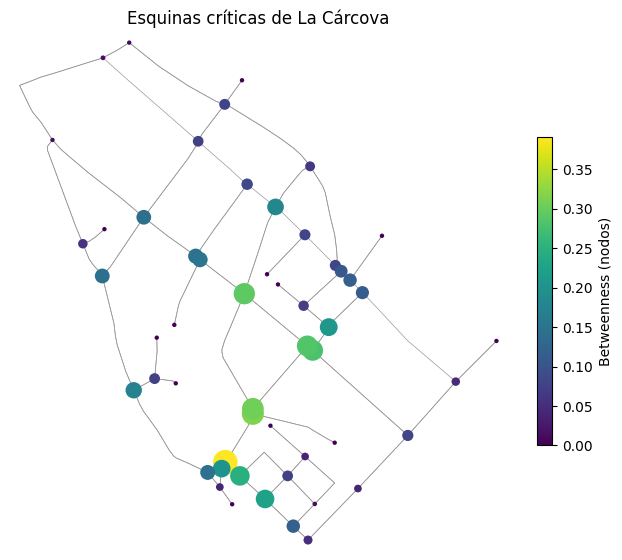

In [22]:
fig, ax = ox.plot_graph(
    G_proj,
    node_color=[nodo_bc[n] for n in G_proj.nodes()],
    node_size=[max(10, 800 * nodo_bc[n]) for n in G_proj.nodes()],
    node_zorder=2, edge_linewidth=0.5, edge_color="#999999",
    bgcolor="white", show=False, close=False,
)

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(vmin=min(nodo_bc.values()), vmax=max(nodo_bc.values())),
)
fig.colorbar(sm, ax=ax, shrink=0.5, label="Betweenness (nodos)")
ax.set_title("Esquinas críticas de La Cárcova")
plt.show()

INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph


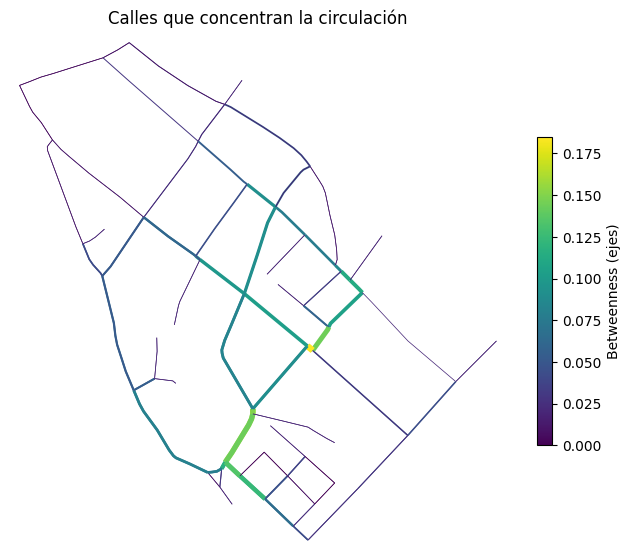

In [23]:
# La misma idea aplicada a los ejes: qué calles concentran el paso
eje_bc = nx.edge_betweenness_centrality(G_proj, weight="length", normalized=True)

# Guardamos la métrica como atributo del eje. Así podemos reutilizar el mismo
# helper de la Sección 4, que traduce un atributo numérico a colores.
nx.set_edge_attributes(G_proj, eje_bc, "betweenness")
colores = ox.plot.get_edge_colors_by_attr(G_proj, attr="betweenness", cmap="viridis")

# El ancho sí acepta números crudos: sólo el color necesita ser un color.
anchos = [max(0.5, 25 * eje_bc[(u, v, k)]) for u, v, k in G_proj.edges(keys=True)]

fig, ax = ox.plot_graph(
    G_proj,
    node_size=0,
    edge_color=colores,
    edge_linewidth=anchos,
    bgcolor="white", show=False, close=False,
)

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(vmin=min(eje_bc.values()), vmax=max(eje_bc.values())),
)
fig.colorbar(sm, ax=ax, shrink=0.5, label="Betweenness (ejes)")
ax.set_title("Calles que concentran la circulación")
plt.show()

> **Una asimetría que conviene tener presente.** `node_color` acepta valores
> numéricos y los mapea con un colormap, pero `edge_color` espera **colores**
> (nombres o tuplas RGBA). Pasarle la métrica en crudo devuelve
> `ValueError: Invalid RGBA argument`. Por eso la celda de nodos funciona con
> `[nodo_bc[n] for n in ...]` y la de ejes necesita traducir a color primero.

Las calles resaltadas son las **troncales internas** del barrio: las que
conectan sectores entre sí. En un tejido informal suelen ser pocas, y eso es
justamente lo que las vuelve un punto de fragilidad.

INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Verified {attr!r} values are numeric and non-null across graph edges.
INFO:OSMnx:Begin plotting the graph...
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Finished plotting the graph


Nodo origen : 684398538
Nodo destino: 2506002702
Ruta de 3 nodos, 205 metros


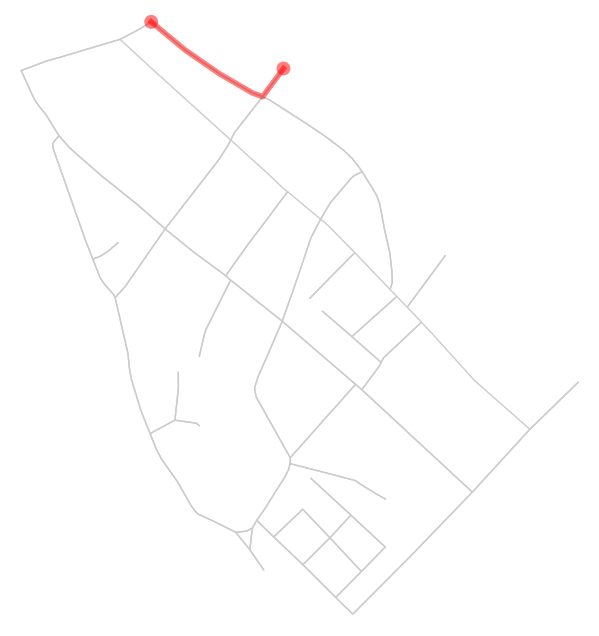

In [24]:
origen = ox.distance.nearest_nodes(G, X=-58.586659, Y=-34.505754)
destino = ox.distance.nearest_nodes(G, X=-58.578000, Y=-34.512000)

ruta = ox.routing.shortest_path(G, origen, destino, weight="length")

largo_m = nx.shortest_path_length(G, origen, destino, weight="length")
print(f"Nodo origen : {origen}")
print(f"Nodo destino: {destino}")
print(f"Ruta de {len(ruta)} nodos, {largo_m:,.0f} metros")

fig, ax = ox.plot_graph_route(
    G, ruta, route_color="red", route_linewidth=4,
    node_size=0, bgcolor="white", edge_color="#cccccc",
)

`nearest_nodes` trabaja en el CRS del grafo. Como `G` está sin proyectar
(lat/lon), se le pasan grados directamente. Si el grafo estuviera proyectado
(`G_proj`), habría que convertir las coordenadas primero — es un error fácil de
cometer y difícil de detectar, porque no falla: devuelve el nodo equivocado.

## Ejercitación

En la Sección 2.1 descargamos la red peatonal de **Villa Hidalgo** y **La
Cárcova**. Compará su topología y respondé: ¿qué diferencias hay en la
movilidad a pie dentro de cada una?

*Sugerencia:* los dos barrios tienen **superficies distintas**, así que las
métricas absolutas (cantidad de nodos, metros totales de calle) no sirven para
compararlos. Elegí métricas que normalicen por área o que sean promedios.

In [ ]:
# Desarrollar ejercicio

INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Validated that node/edge GeoDataFrames can be converted to a MultiDiGraph.
INFO:OSMnx:Created graph from node/edge GeoDataFrames
INFO:OSMnx:Projected graph with 26 nodes and 60 edges
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Converted MultiDiGraph to undirected MultiGraph
INFO:OSMnx:Created nodes GeoDataFrame from graph
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Created edges GeoDataFrame from graph
INFO:OSMnx:Projected GeoDataFrame to 'EPSG:32721 / WGS 84 / UTM zone 21S'
INFO:OSMnx:Validated that node/edge GeoDataFrames can be converted to a MultiDiGraph.
INFO:OSMnx:Created graph from node/edge GeoDataFrames
INFO:OSMnx:Projec

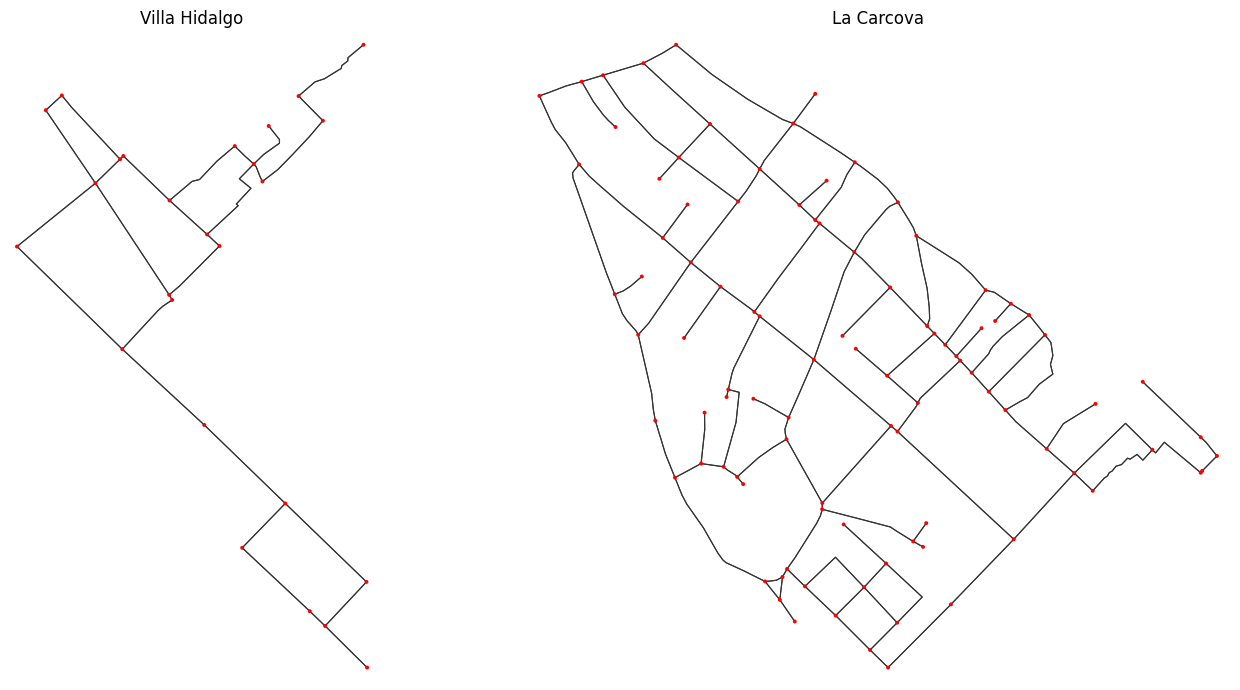

,área_km2,km_calle_km2,calles_x_esquina,%_sin_salida,circuidad,largo_medio_m
barrio,,,,,,
Villa Hidalgo,0.180,12.9,3.19,3.8,1.018,77.6
La Carcova,0.293,25.7,2.71,19.8,1.024,61.6


In [29]:
#@title Solución
def perfil(G, nombre):
    """Métricas topológicas comparables entre redes de distinto tamaño."""
    G_proj = ox.project_graph(G)
    area = ox.graph_to_gdfs(G_proj, edges=False).geometry.union_all().convex_hull.area
    s = ox.basic_stats(G_proj, area=area)

    return {
        "barrio": nombre,
        "área_km2": round(area / 1e6, 3),
        "km_calle_km2": round(s["street_density_km"] / 1000, 1),
        "calles_x_esquina": round(s["streets_per_node_avg"], 2),
        "%_sin_salida": round(100 * s["streets_per_node_proportions"].get(1, 0), 1),
        "circuidad": round(s["circuity_avg"], 3),
        "largo_medio_m": round(s["street_length_avg"], 1),
    }


tabla = pd.DataFrame(perfil(G, n) for n, G in redes_barrios.items()).set_index("barrio")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (nombre, G) in zip(axes, redes_barrios.items()):
    ox.plot_graph(G, ax=ax, show=False, close=False, bgcolor="white",
                  node_color="red", node_size=8, edge_color="#333333", edge_linewidth=0.8)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

tabla

In [31]:
#@title 📌 Ver conclusión
from IPython.display import Markdown, display

display(Markdown("""
### Cómo leer la tabla

**Lo primero es la normalización.** Los dos barrios tienen superficies
distintas, así que "más nodos" o "más metros de calle" solo diría cuál es más
grande. Por eso la tabla usa densidades (por km²) y promedios: son las únicas
métricas que responden a la traza y no al tamaño.

**Qué mira cada una**

- **km de calle por km².** Cuánta vía hay por unidad de superficie. En tejidos
  informales suele ser alta, porque los pasillos son angostos y numerosos.
  Densidad alta no significa buena conectividad.
- **Calles por esquina.** Un damero tiende a 4: cada intersección cruza dos
  calles. Cerca de 3 indica que muchas vías terminan o se ramifican en vez de
  cruzarse.
- **Porcentaje sin salida.** Esquinas con una sola calle. Cada una es un
  recorrido que hay que deshacer.
- **Circuidad.** Cuánto más largo es el camino real que la línea recta. Es la
  métrica que traduce topología a minutos de caminata.

**El efecto sobre la movilidad**

Donde la circuidad es más alta y las calles sin salida más frecuentes, la
distancia recorrida supera a la distancia geográfica y hay menos recorridos
alternativos. Eso es más tiempo caminando hasta una parada o una escuela, y una
red frágil: si se corta uno de los pocos ejes troncales que resaltó la
betweenness en la Sección 5.2, no hay calle paralela que absorba el desvío.
También condiciona el acceso de ambulancias, bomberos y recolección.

**Dos límites**

1. Son métricas puramente topológicas: no saben si la calle está asfaltada,
   iluminada o se inunda.
2. La cobertura de OSM es despareja. Los pasillos internos suelen estar
   **sub-mapeados**, lo que subestima la densidad real. Mirá el plot antes de
   confiar en los números.

**Extensión (si Overpass acompaña)**

Agregá un barrio de traza regular como control y volvé a correr `perfil`:

```python
ballester = ox.graph_from_point(
    ox.geocode("Villa Ballester, Buenos Aires, Argentina"),
    dist=600, dist_type="bbox", network_type="walk")
```

El contraste informal/regular es más marcado que el de dos asentamientos entre
sí, pero requiere una descarga más.
"""))


### Cómo leer la tabla

**Lo primero es la normalización.** Los dos barrios tienen superficies
distintas, así que "más nodos" o "más metros de calle" solo diría cuál es más
grande. Por eso la tabla usa densidades (por km²) y promedios: son las únicas
métricas que responden a la traza y no al tamaño.

**Qué mira cada una**

- **km de calle por km².** Cuánta vía hay por unidad de superficie. En tejidos
  informales suele ser alta, porque los pasillos son angostos y numerosos.
  Densidad alta no significa buena conectividad.
- **Calles por esquina.** Un damero tiende a 4: cada intersección cruza dos
  calles. Cerca de 3 indica que muchas vías terminan o se ramifican en vez de
  cruzarse.
- **Porcentaje sin salida.** Esquinas con una sola calle. Cada una es un
  recorrido que hay que deshacer.
- **Circuidad.** Cuánto más largo es el camino real que la línea recta. Es la
  métrica que traduce topología a minutos de caminata.

**El efecto sobre la movilidad**

Donde la circuidad es más alta y las calles sin salida más frecuentes, la
distancia recorrida supera a la distancia geográfica y hay menos recorridos
alternativos. Eso es más tiempo caminando hasta una parada o una escuela, y una
red frágil: si se corta uno de los pocos ejes troncales que resaltó la
betweenness en la Sección 5.2, no hay calle paralela que absorba el desvío.
También condiciona el acceso de ambulancias, bomberos y recolección.

**Dos límites**

1. Son métricas puramente topológicas: no saben si la calle está asfaltada,
   iluminada o se inunda.
2. La cobertura de OSM es despareja. Los pasillos internos suelen estar
   **sub-mapeados**, lo que subestima la densidad real. Mirá el plot antes de
   confiar en los números.

**Extensión (si Overpass acompaña)**

Agregá un barrio de traza regular como control y volvé a correr `perfil`:

```python
ballester = ox.graph_from_point(
    ox.geocode("Villa Ballester, Buenos Aires, Argentina"),
    dist=600, dist_type="bbox", network_type="walk")
```

El contraste informal/regular es más marcado que el de dos asentamientos entre
sí, pero requiere una descarga más.
